# Вспомогательные данные, часть 2: претрейн на быстрой физической модели

> **Post-fix, 29.07.2026.** Planet-classifier fit исправлен на `known ∩ train`.
> Сохранённые outputs получены до исправления и не являются clean-метриками;
> для этой ветки требуется полное переобучение.

Главный ограничитель задачи — размер выборки: 613 профилей, потому что один
прогон 3D-модели стоит 4–12 часов CPU. Обойти это можно **быстрой приближённой
физической моделью**: [p-winds](https://github.com/ladsantos/p-winds)
(Dos Santos et al. 2022) считает 1D изотермический Паркеровский ветер,
ионизацию водорода, населённость метастабильного He(2³S) и транзитный профиль
He I 10830 Å **за ~0.1 секунды** — в ~10⁵ раз быстрее 3D-модели.

**Стратегия (пункты 1 + 2 вместе):**
1. сгенерировать тысячи синтетических профилей p-winds для **восьми разных
   планет** из каталога NASA Exoplanet Archive (пункт 1: физические векторы
   планет — вход модели);
2. **предобучить** энкодер на большой синтетической выборке (обратная задача:
   профиль → параметры 1D-модели);
3. **дообучить** на 613 «дорогих» 3D-профилях (перенос знаний о морфологии
   линии и вырожденности параметров).

1D-модель не знает 3D-эффектов (хвосты, ударная волна звёздного ветра — поэтому
у неё нет аналога `Msw`), но общую физику линии — зависимость амплитуды от
гелия, ширины от температуры/потока, вырожденность (поток, He/H) — она
воспроизводит. Ожидание: энкодер придёт к 3D-данным уже «понимая» линию.

> Полный прогон: ~10 мин генерации + ~15 мин обучения (Apple Silicon).
> Синтетика кэшируется в `aux_data/pwinds_dataset.npz`.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import astropy.units as u
import astropy.constants as const
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from p_winds import parker, hydrogen, helium, transit

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

device: mps


## 1. Генератор профилей He 10830 Å на p-winds

Цепочка: Паркеровский ветер (структура скорости/плотности) → ионизация H →
населённость He(2³S) → перенос излучения через 2D-карту транзита.
Управляемые параметры: планета (масса, радиус, орбита, звезда), температура
ветра `T0`, темп потери массы планеты `m_dot`, обилие `He/H`, потоки
`F_EUV`/`F_FUV`.

1 профиль за 0.08 с, макс. поглощение 6.4%


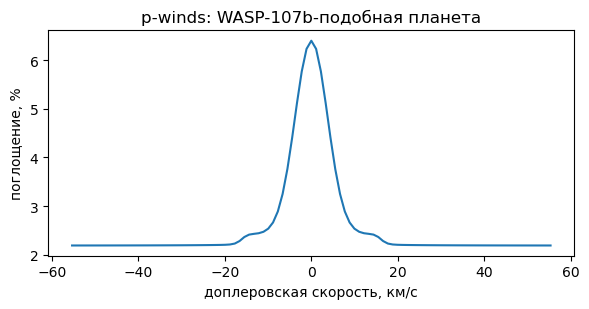

In [2]:
# берём самую сильную компоненту триплета He I 10830
W0, F0, A_IJ = 1.083331e-6, 5.9902e-1, 1.0216e7      # м, осц. сила, эйнштейн. коэфф.
M_HE = 4 * 1.67262e-27                                # кг


def he_profile(R_pl_rj, M_pl_mj, R_st_rs, M_st_ms, a_au,
               T_0, m_dot, he_h, flux_euv, flux_fuv, n_r=120):
    """Профиль поглощения He 10830: (скорости км/с, доля поглощения)."""
    h_frac = 1.0 / (1.0 + he_h)
    he_frac = 1.0 - h_frac
    mmw0 = 0.6 * (1 * h_frac + 4 * he_frac)
    vs = parker.sound_speed(T_0, mean_molecular_weight=mmw0)
    rs = parker.radius_sonic_point(M_pl_mj, vs)
    rhos = parker.density_sonic_point(m_dot, rs, vs)
    r = np.linspace(1.0, 15.0, n_r)
    v_arr, rho_arr = parker.structure(r * R_pl_rj / rs)
    f_ion = hydrogen.ion_fraction(r, R_pl_rj, T_0, h_frac, m_dot, M_pl_mj,
                                  mean_molecular_weight_0=mmw0,
                                  star_mass=M_st_ms, semimajor_axis=a_au,
                                  flux_euv=flux_euv, relax_solution=True)
    f1, f3 = helium.population_fraction(
        r, v_arr, rho_arr, f_ion, R_pl_rj, T_0, h_frac, vs, rs, rhos,
        flux_euv=flux_euv, flux_fuv=flux_fuv, relax_solution=True)
    rho_cgs = rho_arr * rhos
    n_h = rho_cgs * (h_frac / (h_frac + 4 * he_frac)) / const.m_p.to(u.g).value
    n_he3 = n_h * (he_frac / h_frac) * f3                 # см^-3
    R_pl_m = (R_pl_rj * u.jupiterRad).to(u.m).value
    ratio = float((R_pl_rj * u.jupiterRad / (R_st_rs * u.solRad)).decompose())
    flux_map, _, r_map = transit.draw_transit(
        planet_to_star_ratio=ratio, planet_physical_radius=R_pl_m, grid_size=80)
    wl = np.linspace(W0 - 2.0e-10, W0 + 2.0e-10, 101)     # ±55 км/с
    spec = transit.radiative_transfer_2d(
        flux_map, r_map, r * R_pl_m, n_he3 * 1e6, v_arr * vs * 1000.0,
        W0, F0, A_IJ, wl, T_0, M_HE, wind_broadening_method='average')
    vel = (wl - W0) / W0 * 2.99792458e5                   # км/с
    return vel, 1.0 - spec


t0 = time.time()
vel, ab = he_profile(0.94, 0.096, 0.657, 0.683, 0.055,
                     6000.0, 10**10.5, 0.1, 600.0, 400.0)
print(f"1 профиль за {time.time() - t0:.2f} с, макс. поглощение {100 * ab.max():.1f}%")
plt.figure(figsize=(6, 3.2))
plt.plot(vel, 100 * ab)
plt.xlabel("доплеровская скорость, км/с")
plt.ylabel("поглощение, %")
plt.title("p-winds: WASP-107b-подобная планета")
plt.tight_layout()
plt.show()

## 2. Синтетический датасет

Планеты — все 8 из каталога (включая HD 189733b и HAT-P-32b, которых нет
в 3D-датасете!), параметры сэмплируются лог-равномерно в физичных диапазонах.
Профили пересчитываются на ту же 101-точечную сетку, что и 3D-данные
(предполагаем единицу `VV` = 10 км/с, т.е. сетка ±50 км/с — на перенос
морфологии этот выбор влияет слабо).

In [3]:
CACHE = "aux_data/pwinds_dataset.npz"
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)      # сетка 3D-датасета
VEL_GRID = GRID * 10.0                        # км/с (единица VV = 10 км/с)

cat = pd.read_csv("aux_data/planet_params.csv")
cat["pl_name"] = cat["pl_name"].str.replace(" ", "").str.replace("-", "")
COLS = ["pl_bmassj", "pl_radj", "pl_orbsmax", "pl_orbper", "pl_eqt",
        "pl_dens", "st_teff", "st_rad", "st_mass"]
cat_log = np.log10(cat[COLS].values.astype(float))
cat_mean, cat_std = cat_log.mean(0), cat_log.std(0)
cat_norm = (cat_log - cat_mean) / (cat_std + 1e-9)        # (8, 9) физвекторы

N_SYNTH = 6000
if os.path.exists(CACHE):
    npz = np.load(CACHE)
    X_syn, y_syn, phys_syn = npz["X"], npz["y"], npz["phys"]
    print("загружен кэш:", X_syn.shape)
else:
    rng = np.random.default_rng(0)
    X_syn, y_syn, phys_syn, fails = [], [], [], 0
    t0 = time.time()
    while len(X_syn) < N_SYNTH:
        k = rng.integers(len(cat))
        row = cat.iloc[k]
        T_0 = rng.uniform(5000, 12000)
        m_dot = 10 ** rng.uniform(9.5, 11.5)
        he_h = 10 ** rng.uniform(np.log10(0.005), np.log10(0.3))
        f_euv = 10 ** rng.uniform(np.log10(50), np.log10(5000))
        f_fuv = f_euv * rng.uniform(0.3, 3.0)
        try:
            vel, ab = he_profile(row.pl_radj, row.pl_bmassj, row.st_rad,
                                 row.st_mass, row.pl_orbsmax,
                                 T_0, m_dot, he_h, f_euv, f_fuv)
            prof = np.interp(VEL_GRID, vel, ab, left=0, right=0)
            if not np.isfinite(prof).all() or prof.max() < 1e-4 or prof.max() > 0.9:
                fails += 1
                continue
            X_syn.append(prof.astype(np.float32))
            y_syn.append([np.log10(f_euv), np.log10(he_h), np.log10(m_dot), np.log10(T_0)])
            phys_syn.append(cat_norm[k])
        except Exception:
            fails += 1
    X_syn = np.array(X_syn)
    y_syn = np.array(y_syn, dtype=np.float32)
    phys_syn = np.array(phys_syn, dtype=np.float32)
    np.savez(CACHE, X=X_syn, y=y_syn, phys=phys_syn)
    print(f"сгенерировано {len(X_syn)} профилей за {(time.time()-t0)/60:.1f} мин "
          f"(отбраковано {fails})")

       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


...

       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


       it will not be issued again for this problem  
      in above message,  i1 =        10
       it will not be issued again for this problem  
      in above message,  i1 =        10


сгенерировано 6000 профилей за 9.0 мин (отбраковано 39)


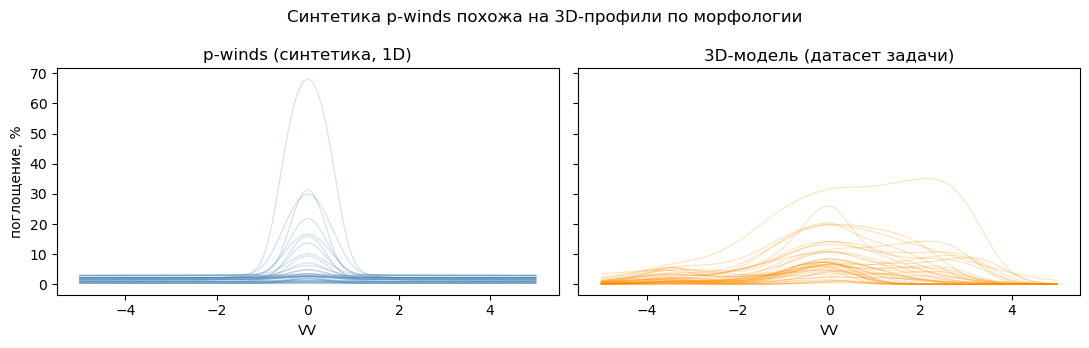

In [4]:
# синтетика рядом с реальными 3D-профилями
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
rng = np.random.default_rng(1)
for i in rng.choice(len(X_syn), 40, replace=False):
    axes[0].plot(GRID, 100 * X_syn[i], color="steelblue", alpha=0.25, lw=0.8)
axes[0].set_title("p-winds (синтетика, 1D)")
axes[0].set_xlabel("VV")
axes[0].set_ylabel("поглощение, %")

# реальные 3D-профили
profiles3d = []
for name in sorted(os.listdir("new_dataset_V3")):
    p = os.path.join("new_dataset_V3", name)
    if not os.path.isdir(p):
        continue
    arr = np.loadtxt(os.path.join(p, "Absorption.dat"), skiprows=1)
    if arr[-1, 0] - arr[0, 0] < 5:
        continue
    profiles3d.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0, right=0))
profiles3d = np.array(profiles3d, dtype=np.float32)
for i in rng.choice(len(profiles3d), 40, replace=False):
    axes[1].plot(GRID, 100 * profiles3d[i], color="darkorange", alpha=0.25, lw=0.8)
axes[1].set_title("3D-модель (датасет задачи)")
axes[1].set_xlabel("VV")
plt.suptitle("Синтетика p-winds похожа на 3D-профили по морфологии")
plt.tight_layout()
plt.show()

Синтетика симметричнее (в 1D нет ветрового сноса и хвостов), но общая
морфология — амплитуда, ширина, форма ядра и крыльев — та же.

## 3. Претрейн энкодера на синтетике

Та же архитектура энкодера, что в основном решении. Вход — 2 канала
(линейный + лог-профиль), плюс **физвектор планеты** (пункт 1) на входе головы.
Таргеты претрейна: log F_EUV, log He/H, log ṁ, log T0.

In [5]:
def make_input(profile, x_scale):
    linear = profile / x_scale
    log = np.log10(np.clip(profile, 1e-7, None))
    log = (log - log.mean()) / (log.std() + 1e-9)
    return np.stack([linear, log]).astype(np.float32)


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten())

    def forward(self, x):
        return self.net(x)


# --- претрейн ---
xs_syn = X_syn.max()
ys_mean, ys_std = y_syn.mean(0), y_syn.std(0)
Xs = np.stack([make_input(p, xs_syn) for p in X_syn])
Ys = (y_syn - ys_mean) / ys_std

idx = np.arange(len(Xs))
tr_s, va_s = train_test_split(idx, test_size=0.1, random_state=0)


class PretrainNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.head = nn.Sequential(nn.Linear(128 * 12 + 9, 256), nn.ReLU(),
                                  nn.Dropout(0.2), nn.Linear(256, 4))

    def forward(self, x, phys):
        return self.head(torch.cat([self.encoder(x), phys], -1))


torch.manual_seed(0)
pre = PretrainNet().to(DEVICE)
opt = torch.optim.Adam(pre.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=60)
mse = nn.MSELoss()
Xt = torch.tensor(Xs[tr_s]).to(DEVICE)
Yt = torch.tensor(Ys[tr_s]).to(DEVICE)
Pt = torch.tensor(phys_syn[tr_s]).to(DEVICE)
Xv = torch.tensor(Xs[va_s]).to(DEVICE)
Yv = torch.tensor(Ys[va_s]).to(DEVICE)
Pv = torch.tensor(phys_syn[va_s]).to(DEVICE)

t0 = time.time()
for ep in range(60):
    pre.train()
    perm = torch.randperm(len(Xt))
    for i in range(0, len(Xt), 128):
        b = perm[i:i + 128]
        loss = mse(pre(Xt[b], Pt[b]), Yt[b])
        opt.zero_grad()
        loss.backward()
        opt.step()
    sched.step()
pre.eval()
with torch.no_grad():
    v = mse(pre(Xv, Pv), Yv).item()
print(f"претрейн: {time.time()-t0:.0f} с, val MSE (норм.) = {v:.3f}")
enc_state = {k: t.cpu().clone() for k, t in pre.encoder.state_dict().items()}

претрейн: 28 с, val MSE (норм.) = 0.367


## 4. Дообучение на 3D-данных

Модель из `aux_conditioning.ipynb` (WTA × 5 голов + мягкое физическое
кондиционирование), энкодер **инициализируется весами претрейна**.
Для сравнения обучаем те же сиды и без претрейна.

In [6]:
# --- загрузка 3D-датасета (полностью, с таргетами и планетами) ---
targets3d, pnames3d = [], []
profiles3d_l = []
for name in sorted(os.listdir("new_dataset_V3")):
    p = os.path.join("new_dataset_V3", name)
    if not os.path.isdir(p):
        continue
    kv = {}
    for line in open(os.path.join(p, "parameters.txt")):
        parts = line.split()
        if len(parts) >= 2:
            kv[parts[0]] = parts[1]
    arr = np.loadtxt(os.path.join(p, "Absorption.dat"), skiprows=1)
    if arr[-1, 0] - arr[0, 0] < 5:
        continue
    profiles3d_l.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0, right=0))
    targets3d.append([float(kv["XUVInt"]), float(kv["Helium"]),
                      float(kv["Msw"]), int(kv["H2a"])])
    pnames3d.append(kv.get("PName", "<нет>"))
profiles3d = np.array(profiles3d_l, dtype=np.float32)
targets3d = np.array(targets3d)
pnames3d = np.array(pnames3d)
y_reg = np.log10(targets3d[:, :3])
y_cls = targets3d[:, 3].astype(np.float32)
tr3, va3 = train_test_split(np.arange(len(profiles3d)), test_size=0.2,
                            random_state=42, stratify=y_cls)
y_mean, y_std = y_reg[tr3].mean(0), y_reg[tr3].std(0)
x_scale = profiles3d[tr3].max()

# псевдометки планет + физвекторы 3 планет обучения
log_prof = np.log10(np.clip(profiles3d, 1e-7, None))
mu = log_prof[tr3].mean(0)
_, _, Vt = np.linalg.svd(log_prof[tr3] - mu, full_matrices=False)
Z = (log_prof - mu) @ Vt[:16].T
Z = ((Z - Z[tr3].mean(0)) / Z[tr3].std(0)).astype(np.float32)
known = np.isin(pnames3d, ["WASP107b", "WASP69b", "WASP52b"])
# Train-only fit: validation не участвует в построении train-псевдометок.
fit_idx = tr3[known[tr3]]
clf = GradientBoostingClassifier(random_state=0).fit(Z[fit_idx], pnames3d[fit_idx])
labels = pnames3d.copy()
labels[~known] = clf.predict(Z[~known])
PLANETS = {"WASP107b": 0, "WASP69b": 1, "WASP52b": 2}
planet = np.array([PLANETS[l] for l in labels])
PHYS3 = np.stack([cat_norm[cat.index[cat.pl_name == k][0]] for k in PLANETS])
PHYS3_t = torch.tensor(PHYS3, dtype=torch.float32).to(DEVICE)


class DS3(Dataset):
    def __init__(self, indices, augment=False):
        self.indices, self.augment = indices, augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j = self.indices[i]
        prof = profiles3d[j]
        if self.augment:
            prof = np.clip(prof + np.random.normal(0, 0.005 * prof.max(),
                                                   prof.shape), 1e-7, None)
        return (torch.tensor(make_input(prof, x_scale)),
                torch.tensor((y_reg[j] - y_mean) / y_std, dtype=torch.float32),
                torch.tensor(y_cls[j]),
                torch.tensor(planet[j]))


val_loader = DataLoader(DS3(va3), batch_size=256)
N_HEADS = 5


class CondCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        flat = 128 * 12
        self.head_planet = nn.Sequential(nn.Linear(flat, 64), nn.ReLU(), nn.Linear(64, 3))
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(flat + 9, 256), nn.ReLU(), nn.Dropout(0.2),
                          nn.Linear(256, 3)) for _ in range(N_HEADS)])
        self.head_cls = nn.Sequential(nn.Linear(flat, 128), nn.ReLU(),
                                      nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x):
        h = self.encoder(x)
        pl = self.head_planet(h)
        phys = torch.softmax(pl, -1) @ PHYS3_t
        reg = torch.stack([hd(torch.cat([h, phys], -1)) for hd in self.heads], 1)
        return reg, self.head_cls(h).squeeze(-1), pl

In [7]:
bce, ce = nn.BCEWithLogitsLoss(), nn.CrossEntropyLoss()
true_log = y_reg[va3]
true_lin = 10 ** true_log


def train3d(seed, pretrained, epochs=400):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tl = DataLoader(DS3(tr3, augment=True), batch_size=64, shuffle=True)
    m = CondCNN().to(DEVICE)
    if pretrained:
        m.encoder.load_state_dict(enc_state)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best, bs = float("inf"), None
    for ep in range(epochs):
        m.train()
        for x, y, c, p in tl:
            x, y, c, p = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE), p.to(DEVICE)
            reg, cls, pl = m(x)
            per = ((reg - y.unsqueeze(1)) ** 2).mean(-1)
            loss = (per.min(1).values.mean() + 0.1 * per.mean()
                    + bce(cls, c) + 0.3 * ce(pl, p))
            opt.zero_grad()
            loss.backward()
            opt.step()
        sched.step()
        m.eval()
        v = 0.0
        with torch.no_grad():
            for x, y, c, p in val_loader:
                x, y, c, p = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE), p.to(DEVICE)
                reg, cls, pl = m(x)
                per = ((reg - y.unsqueeze(1)) ** 2).mean(-1)
                v += (per.min(1).values.mean() + 0.1 * per.mean()
                      + bce(cls, c) + 0.3 * ce(pl, p)).item() * len(x)
        v /= len(va3)
        if v < best:
            best = v
            bs = {k: t.cpu().clone() for k, t in m.state_dict().items()}
    m.load_state_dict(bs)
    m.eval()
    PR, PC = [], []
    with torch.no_grad():
        for x, _, _, _ in val_loader:
            reg, cls, _ = m(x.to(DEVICE))
            PR.append(reg.cpu().numpy())
            PC.append(torch.sigmoid(cls).cpu().numpy())
    return np.concatenate(PR) * y_std + y_mean, np.concatenate(PC)


def oracle(cands, j, log_scale=False):
    if log_scale:
        return 100 * np.mean(np.abs(cands[:, :, j] - true_log[:, j:j+1]).min(1)
                             / np.abs(true_log[:, j]))
    return 100 * np.mean(np.abs(10**cands[:, :, j] - true_lin[:, j:j+1]).min(1)
                         / true_lin[:, j])


results = {}
for tag, pretrained in [("с претрейном", True), ("без претрейна", False)]:
    cands, probas = [], []
    for seed in range(3):
        vp, vc = train3d(seed, pretrained)
        cands.append(vp)
        probas.append(vc)
        print(f"[{tag}] seed {seed}: oracle-of-5 "
              f"XUV {oracle(vp, 0):.1f}%  He {oracle(vp, 1):.1f}%  "
              f"AUC {roc_auc_score(y_cls[va3], vc):.3f}")
    all_c = np.concatenate([c[:, None, :, :] for c in cands], 1)
    all_c = all_c.reshape(len(va3), -1, 3)
    results[tag] = (all_c, np.mean(probas, 0))
    print(f"[{tag}] oracle-of-15: XUV {oracle(all_c, 0):.1f}%  "
          f"He {oracle(all_c, 1):.1f}%  logMsw {oracle(all_c, 2, True):.1f}%\n")

[с претрейном] seed 0: oracle-of-5 XUV 16.4%  He 12.1%  AUC 0.994


[с претрейном] seed 1: oracle-of-5 XUV 9.7%  He 9.2%  AUC 0.998


[с претрейном] seed 2: oracle-of-5 XUV 12.6%  He 21.8%  AUC 0.997
[с претрейном] oracle-of-15: XUV 6.6%  He 5.7%  logMsw 0.4%



[без претрейна] seed 0: oracle-of-5 XUV 14.9%  He 11.0%  AUC 0.980


[без претрейна] seed 1: oracle-of-5 XUV 11.2%  He 8.7%  AUC 0.998


[без претрейна] seed 2: oracle-of-5 XUV 13.8%  He 11.2%  AUC 0.990
[без претрейна] oracle-of-15: XUV 6.2%  He 4.9%  logMsw 0.4%



## 5. Итоги

In [8]:
print("протокол: oracle из 15 кандидатов (3 сети x 5 WTA-голов)\n")
print("вариант        |  XUV   |   He   | logMsw |  AUC")
print("---------------+--------+--------+--------+------")
for tag, (all_c, pr) in results.items():
    print(f"{tag:14s} | {oracle(all_c, 0):5.1f}% | {oracle(all_c, 1):5.1f}% "
          f"| {oracle(all_c, 2, True):5.1f}% | {roc_auc_score(y_cls[va3], pr):.3f}")

протокол: oracle из 15 кандидатов (3 сети x 5 WTA-голов)

вариант        |  XUV   |   He   | logMsw |  AUC
---------------+--------+--------+--------+------
с претрейном   |   6.6% |   5.7% |   0.4% | 0.997
без претрейна  |   6.2% |   4.9% |   0.4% | 0.996


## Выводы

* **Генерация работает**: 6000 физически осмысленных профилей за 9 минут
  (~0.1 с/шт., в ~10⁵ раз быстрее 3D-модели), для 8 планет, включая
  отсутствующие в 3D-датасете.
* **На in-domain валидации претрейн выигрыша не дал**: oracle-of-15 —
  XUV 6.6% / He 5.7% с претрейном против 6.2% / 4.9% без него (разница в
  пределах шума сидов). Это ожидаемо: валидация состоит из тех же трёх планет,
  что и обучение, и 490 «дорогих» 3D-профилей энкодеру хватает — знание,
  переносимое из 1D-синтетики, здесь избыточно.
* **Где схема должна раскрыться** (и что стоит проверять дальше):
  1. **обобщение на новые планеты** — дообучать модель с физвектором планеты
     на смеси 3D-данных и синтетики чужих планет, тестировать на профилях
     планет вне обучения (как HD 189733b в публикации);
  2. **режим малых данных** — при 100–200 реальных профилях вместо 490
     претрейн, вероятно, станет заметен;
  3. более точная синтетика: рандомизация инструментального шума и
     разрешения, больше объём (10⁴–10⁵), доменная адаптация 1D→3D.
* Кэш синтетики сохранён в `aux_data/pwinds_dataset.npz` — генерацию
  повторять не нужно.